# MNIST, Multi-Layer Perceptron (MLP)

### MNIST由手寫阿拉伯數字組成，包含60,000個訓練樣本和10,000個測試樣本。

##### data from: https://keras.io/datasets/#mnist-database-of-handwritten-digits
##### code modified from: TensorFlow+Keras[深度學習]人工智慧實務應用 / 林大貴


# (1) Import the data from Keras

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# for tensorflow 2.0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow import keras

In [3]:
np.random.seed(3)

In [4]:
# Dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

(x_train_image, y_train_label), (x_test_image, y_test_label) = keras.datasets.mnist.load_data()

print(x_train_image.shape)
print(y_train_label.shape)
print(x_test_image.shape)
print(y_test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# (2) View the first 10 images and labels

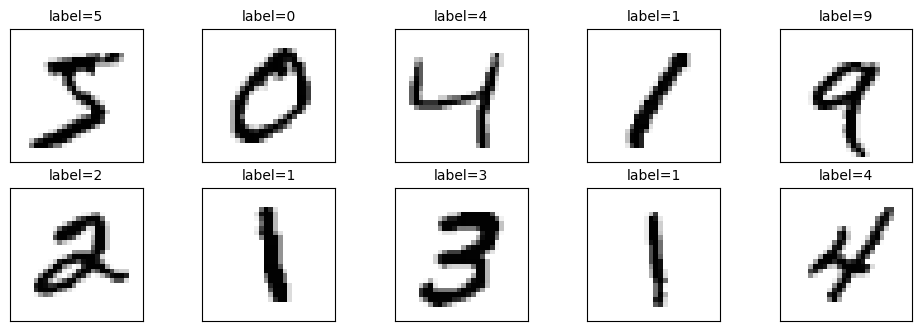

In [5]:
fig = plt.gcf()
fig.set_size_inches(12,10)

for i in range(0,10):
    ax=plt.subplot(5,5,1+i)
    ax.imshow(x_train_image[i], cmap='binary')
    title= "label=" +str(y_train_label[i])
    ax.set_title(title,fontsize=10) 
    ax.set_xticks([]);ax.set_yticks([])        
plt.show()

# (3) Convert 2-D image to 1-D array, normalize the numbers

In [6]:
# convert 2-D 28x28 image to 1-D 784 array

x_Train =x_train_image.reshape(60000, 784).astype('float32')
x_Test = x_test_image.reshape(10000, 784).astype('float32')

In [7]:
# normalize the image numbers to 0~1

x_Train_normalize = x_Train / 255
x_Test_normalize = x_Test / 255
print(x_Train_normalize.shape)
print(x_Test_normalize.shape)

(60000, 784)
(10000, 784)


# (4) Convert label number to one-hot encoding

In [8]:
# convert label numbers to one-hot encoding
y_Train_OneHot = to_categorical(y_train_label)
y_Test_OneHot = to_categorical(y_test_label)
print(y_Train_OneHot.shape)
print(y_Test_OneHot.shape)

(60000, 10)
(10000, 10)


# (5) Use a fully connected ANN

In [9]:
model = Sequential()

In [10]:
model.add(Dense(units=16, 
                input_dim=784, 
                kernel_initializer='normal', 
                activation='relu'))

In [11]:
model.add(Dense(units=10, 
                kernel_initializer='normal', 
                activation='softmax'))

In [12]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                12560     
                                                                 
 dense_1 (Dense)             (None, 10)                170       
                                                                 
Total params: 12730 (49.73 KB)
Trainable params: 12730 (49.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


# (6) Model training

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

Fixing the KeyError: ‘acc’ and KeyError: ‘val_acc’ Errors in Keras 2.3.x or Newer
If you’re getting errors such as KeyError: ‘acc’ or KeyError: ‘val_acc’ in your Keras code, it may be due to a recent change in Keras 2.3.x.

https://towardsdatascience.com/fixing-the-keyerror-acc-and-keyerror-val-acc-errors-in-keras-2-3-x-or-newer-b29b52609af9

In [13]:
model.compile(loss='categorical_crossentropy', 
              optimizer='adam', metrics=['accuracy'])

In [14]:
train_history =model.fit(x=x_Train_normalize,
                         y=y_Train_OneHot,validation_split=0.2, 
                         epochs=20, batch_size=50,verbose=2)

Epoch 1/20
960/960 - 2s - loss: 0.6077 - accuracy: 0.8361 - val_loss: 0.3014 - val_accuracy: 0.9155 - 2s/epoch - 2ms/step
Epoch 2/20
960/960 - 1s - loss: 0.2967 - accuracy: 0.9165 - val_loss: 0.2601 - val_accuracy: 0.9252 - 1s/epoch - 1ms/step
Epoch 3/20
960/960 - 1s - loss: 0.2597 - accuracy: 0.9259 - val_loss: 0.2405 - val_accuracy: 0.9308 - 1s/epoch - 1ms/step
Epoch 4/20
960/960 - 1s - loss: 0.2363 - accuracy: 0.9322 - val_loss: 0.2285 - val_accuracy: 0.9351 - 1s/epoch - 1ms/step
Epoch 5/20
960/960 - 1s - loss: 0.2181 - accuracy: 0.9372 - val_loss: 0.2116 - val_accuracy: 0.9401 - 1s/epoch - 1ms/step
Epoch 6/20
960/960 - 1s - loss: 0.2029 - accuracy: 0.9415 - val_loss: 0.2000 - val_accuracy: 0.9446 - 1s/epoch - 1ms/step
Epoch 7/20
960/960 - 1s - loss: 0.1906 - accuracy: 0.9446 - val_loss: 0.1899 - val_accuracy: 0.9470 - 1s/epoch - 1ms/step
Epoch 8/20
960/960 - 1s - loss: 0.1801 - accuracy: 0.9471 - val_loss: 0.1848 - val_accuracy: 0.9473 - 1s/epoch - 1ms/step
Epoch 9/20
960/960 - 1s 

# (7) Training history

In [15]:
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

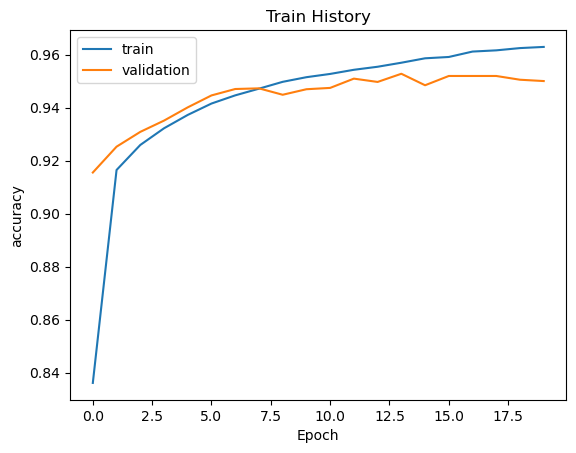

In [16]:
show_train_history(train_history,'accuracy','val_accuracy')

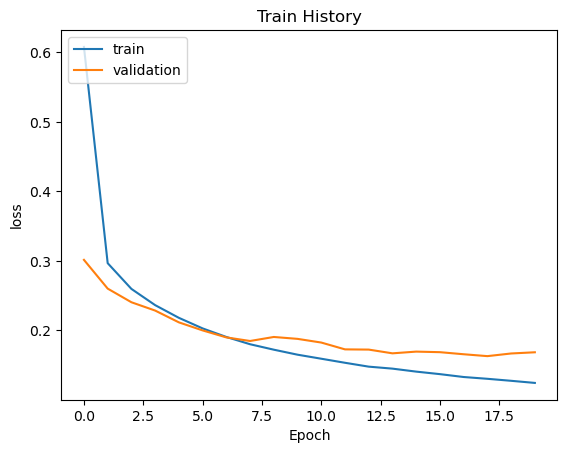

In [17]:
show_train_history(train_history,'loss','val_loss')

# (8) Accuracy

In [18]:
scores = model.evaluate(x_Test_normalize, y_Test_OneHot)
print()
print('accuracy=',scores[1])

313/313 [==============================] - 1s 1ms/step - loss: 0.1687 - accuracy: 0.9512

accuracy= 0.951200008392334


# (9) Prediction

In [19]:
predict_prob = model.predict(x_Test_normalize)
prediction = np.argmax(predict_prob,axis=1)
print(prediction)

313/313 [==============================] - 0s 879us/step
[7 2 1 ... 4 5 6]


In [20]:
def plot_images_labels_prediction(images,labels,prediction,
                                  idx,num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 10)
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[idx], cmap='binary')
        title= "label=" +str(labels[idx])
        if len(prediction)>0:
            title+=",predict="+str(prediction[idx]) 
            
        ax.set_title(title,fontsize=10) 
        ax.set_xticks([]);ax.set_yticks([])        
        idx+=1 
    plt.show()

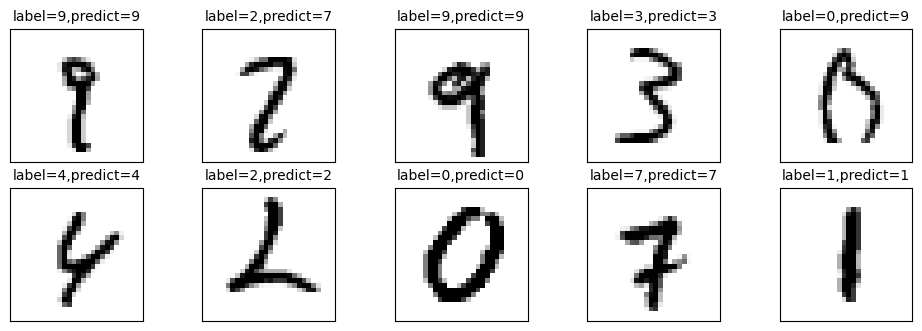

In [21]:
plot_images_labels_prediction(x_test_image,y_test_label,
                              prediction,idx=320)

# (10) Confusion matrix

In [22]:
pd.crosstab(y_test_label,prediction,
            rownames=['label'],colnames=['predict'])

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,955,0,1,3,3,6,8,2,1,1
1,0,1113,4,3,0,1,2,3,9,0
2,8,7,969,10,7,1,4,9,16,1
3,6,0,6,950,1,16,0,7,16,8
4,2,0,5,1,929,1,6,4,2,32
5,5,2,1,15,1,822,13,4,22,7
6,8,3,1,0,4,12,925,0,5,0
7,0,7,12,6,3,2,0,982,0,16
8,4,4,1,15,6,8,5,7,911,13
